In [13]:
import numpy
print(numpy.__version__)

1.24.4


In [14]:
import pandas as pd
import numpy as np
np.bool = bool  # temporary compatibility shim
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Load train.csv
data_dir = Path("../data")
train_df = pd.read_csv(data_dir / "lead_futures_with_features.csv", index_col=0, parse_dates=True)

print(f"Train data shape: {train_df.shape}")
print(f"Date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nFirst few rows:")
train_df.head()


Train data shape: (2738, 20)
Date range: 2015-01-02 00:00:00 to 2025-10-31 00:00:00

Columns: ['Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct', 'Returns_1d', 'Returns_7d', 'Returns_14d', 'Volatility_7d', 'Volatility_14d', 'Volatility_21d', 'Volume_Log', 'Volume_Change_Pct', 'Price_MA7_Ratio', 'Price_MA30_Ratio', 'MA14_MA30_Ratio', 'RSI', 'MACD', 'BB_Position']

First few rows:


,Close,Open,High,Low,Volume,Change_Pct,Returns_1d,Returns_7d,Returns_14d,Volatility_7d,Volatility_14d,Volatility_21d,Volume_Log,Volume_Change_Pct,Price_MA7_Ratio,Price_MA30_Ratio,MA14_MA30_Ratio,RSI,MACD,BB_Position
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,1869.00,1856.75,1876.25,1835.0,2920.0,0.0066,NaN,NaN,NaN,NaN,NaN,NaN,7.979681,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
2015-01-05,1841.50,1870.25,1878.50,1840.0,3380.0,-0.0147,-0.014714,NaN,NaN,NaN,NaN,NaN,8.125927,0.157534,NaN,NaN,NaN,NaN,-2.193732,NaN
2015-01-06,1842.75,1840.00,1863.00,1838.0,3340.0,0.0007,0.000679,NaN,NaN,NaN,NaN,NaN,8.114025,-0.011834,NaN,NaN,NaN,NaN,-3.787753,NaN
2015-01-07,1842.50,1842.75,1850.25,1824.0,3220.0,-0.0001,-0.000136,NaN,NaN,NaN,NaN,NaN,8.077447,-0.035928,NaN,NaN,NaN,NaN,-5.013408,NaN
2015-01-08,1852.00,1842.00,1873.25,1842.0,3580.0,0.0052,0.005156,NaN,NaN,NaN,NaN,NaN,8.183397,0.111801,NaN,NaN,NaN,NaN,-5.158711,NaN


In [16]:
# Remove the first 200 rows
original_shape = train_df.shape
train_df = train_df.iloc[200:].copy()

print(f"Original shape: {original_shape}")
print(f"New shape: {train_df.shape}")
print(f"Removed {original_shape[0] - train_df.shape[0]} rows")
print(f"\nNew date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"\nFirst few rows after removal:")
train_df.head()


Original shape: (1916, 23)
New shape: (1716, 23)
Removed 200 rows

New date range: 2015-10-16 00:00:00 to 2022-08-01 00:00:00

First few rows after removal:


,Close,Open,High,Low,Volume,Change_Pct,Returns_1d,Returns_7d,Returns_14d,Volatility_7d,...,Volume_Change_Pct,Price_MA7_Ratio,Price_MA30_Ratio,MA14_MA30_Ratio,RSI,MACD,BB_Position,Forward_Return_30,Target_30d_Up,Target
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,1803.0,1796.0,1813.0,1790.0,2330.0,0.0039,0.003898,0.077061,0.084185,0.403181,...,-0.133829,1.015938,1.059477,1.006192,71.212121,26.017969,0.896624,-0.103993,0,0
2015-10-19,1789.0,1810.0,1810.5,1787.0,1980.0,-0.0078,-0.007765,0.070296,0.077062,0.412935,...,-0.150215,0.998605,1.048847,1.009252,68.713450,27.573793,0.809454,-0.081610,0,0
2015-10-20,1780.5,1781.0,1792.0,1775.0,2090.0,-0.0048,-0.004751,0.001125,0.065530,0.170113,...,0.055556,0.993701,1.042000,1.012028,66.079295,27.800450,0.752081,-0.069924,0,0
2015-10-21,1735.0,1770.5,1782.0,1727.0,2750.0,-0.0256,-0.025555,-0.038248,0.056960,0.197197,...,0.315789,0.973664,1.014897,1.015461,63.113604,24.031587,0.574850,-0.050432,0,0
2015-10-22,1758.0,1739.0,1779.5,1729.5,2450.0,0.0133,0.013256,-0.009577,0.062557,0.209228,...,-0.109091,0.987918,1.027690,1.019130,64.120055,22.639667,0.646774,-0.060865,0,0


In [ ]:
# PCA Analysis to determine top 10 features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print explained variance for first 10 components
print("Explained Variance Ratio for first 10 components:")
for i in range(min(10, len(explained_variance))):
    print(f"PC{i+1}: {explained_variance[i]:.4f} ({explained_variance[i]*100:.2f}%)")

print(f"\nCumulative variance for first 10 components: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%)")

# Get component loadings (correlations between features and principal components)
component_loadings = pca.components_.T  # Transpose to get features x components

# Calculate feature importance based on absolute loadings across top components
# We'll use the first 10 components to determine top features
n_components_to_use = min(10, len(pca.components_))
feature_importance = np.abs(component_loadings[:, :n_components_to_use]).sum(axis=1)

# Create DataFrame with feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Features based on PCA:")
print(feature_importance_df.head(10).to_string(index=False))

# Visualize explained variance
plt.figure(figsize=(12, 5))

# Plot 1: Explained variance per component
plt.subplot(1, 2, 1)
plt.bar(range(1, min(11, len(explained_variance)+1)), explained_variance[:10])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.xticks(range(1, min(11, len(explained_variance)+1)))

# Plot 2: Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, min(11, len(cumulative_variance)+1)), cumulative_variance[:10], marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.legend()
plt.xticks(range(1, min(11, len(cumulative_variance)+1)))

plt.tight_layout()
plt.show()

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_10_features = feature_importance_df.head(10)
plt.barh(range(len(top_10_features)), top_10_features['Importance'].values)
plt.yticks(range(len(top_10_features)), top_10_features['Feature'].values)
plt.xlabel('Feature Importance (Sum of Absolute Loadings)')
plt.title('Top 10 Features Based on PCA')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Store top 10 feature names
top_10_feature_names = top_10_features['Feature'].tolist()
print(f"\nTop 10 Feature Names:")
print(top_10_feature_names)


In [17]:
# Extract features (X) - exclude target variables
irr_cols = ['Close', 'Open', 'High', 'Low', 'Volume', 'Target', 'Target_30d_Up', 
            'Forward_Return_30', 'Year', 'Month', 'DayOfWeek', 'DayOfMonth']
X = train_df.drop(columns=irr_cols, errors='ignore')

print(f"Feature matrix X shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature columns:")
print(list(X.columns))
print(f"\nFirst few rows of X:")
X.head()


Feature matrix X shape: (1716, 15)
Number of features: 15

Feature columns:
['Change_Pct', 'Returns_1d', 'Returns_7d', 'Returns_14d', 'Volatility_7d', 'Volatility_14d', 'Volatility_21d', 'Volume_Log', 'Volume_Change_Pct', 'Price_MA7_Ratio', 'Price_MA30_Ratio', 'MA14_MA30_Ratio', 'RSI', 'MACD', 'BB_Position']

First few rows of X:


,Change_Pct,Returns_1d,Returns_7d,Returns_14d,Volatility_7d,Volatility_14d,Volatility_21d,Volume_Log,Volume_Change_Pct,Price_MA7_Ratio,Price_MA30_Ratio,MA14_MA30_Ratio,RSI,MACD,BB_Position
Date,,,,,,,,,,,,,,,
2015-10-16,0.0039,0.003898,0.077061,0.084185,0.403181,0.338214,0.300158,7.754053,-0.133829,1.015938,1.059477,1.006192,71.212121,26.017969,0.896624
2015-10-19,-0.0078,-0.007765,0.070296,0.077062,0.412935,0.342046,0.291615,7.591357,-0.150215,0.998605,1.048847,1.009252,68.713450,27.573793,0.809454
2015-10-20,-0.0048,-0.004751,0.001125,0.065530,0.170113,0.344786,0.291129,7.645398,0.055556,0.993701,1.042000,1.012028,66.079295,27.800450,0.752081
2015-10-21,-0.0256,-0.025555,-0.038248,0.056960,0.197197,0.356182,0.303543,7.919720,0.315789,0.973664,1.014897,1.015461,63.113604,24.031587,0.574850
2015-10-22,0.0133,0.013256,-0.009577,0.062557,0.209228,0.357980,0.306133,7.804251,-0.109091,0.987918,1.027690,1.019130,64.120055,22.639667,0.646774


In [18]:
# Features data description
stat = X.describe(percentiles=[.01,.05,.5,.95,.99]).T
stat['missing'] = X.isna().sum()
stat['skew'] = X.skew(numeric_only=True)
stat['kurt'] = X.kurt(numeric_only=True)

# IQR outliers (outside [Q1-3*IQR, Q3+3*IQR])
q1, q3 = X.quantile(.25), X.quantile(.75)
iqr = q3 - q1
out_mask = (X.lt(q1 - 3*iqr)) | (X.gt(q3 + 3*iqr))
stat['outliers_iqr3'] = out_mask.sum()

# Robust MAD z-score (good for heavy tails)
med = X.median()
mad = (X - med).abs().median() * 1.4826
mad_z = (X - med).div(mad.replace(0, np.nan)).abs()
stat['outliers_mad5'] = (mad_z > 5).sum()

stat.sort_values('outliers_mad5', ascending=False)

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing,skew,kurt,outliers_iqr3,outliers_mad5
Volume_Log,1716.0,8.733244,0.911361,5.802118,7.734977,7.954547,8.114025,10.818288,11.130641,11.681326,0,1.204853,0.511262,0,680
Volume_Change_Pct,1716.0,0.048227,0.738353,-0.973171,-0.466346,-0.308439,0.000000,0.474921,1.075203,22.151515,0,24.710422,690.370602,639,600
Volatility_7d,1716.0,0.210209,0.084954,0.036333,0.071878,0.103044,0.195582,0.362873,0.520618,0.656700,0,1.324805,3.288638,12,12
Change_Pct,1716.0,0.000178,0.014133,-0.062500,-0.034170,-0.022200,0.000400,0.022825,0.034770,0.085000,0,0.086050,1.696253,2,1
Returns_1d,1716.0,0.000178,0.014133,-0.062536,-0.034204,-0.022193,0.000395,0.022848,0.034761,0.085007,0,0.085867,1.696376,2,1
Volatility_21d,1716.0,0.218336,0.056251,0.087716,0.125906,0.143110,0.210022,0.315229,0.412088,0.440999,0,1.106166,1.780200,3,1
Price_MA7_Ratio,1716.0,1.000283,0.018247,0.927262,0.953149,0.970274,1.000223,1.029609,1.041927,1.090918,0,-0.026836,0.872942,1,1
Returns_7d,1716.0,0.001196,0.035294,-0.129709,-0.081092,-0.057207,0.001096,0.059091,0.088947,0.122355,0,0.014678,0.418946,0,0
Returns_14d,1716.0,0.002523,0.049690,-0.145258,-0.116904,-0.078667,0.003602,0.082566,0.125898,0.166218,0,0.053015,0.105718,0,0
Volatility_14d,1716.0,0.216218,0.065826,0.081937,0.104649,0.130815,0.206606,0.333073,0.449858,0.479212,0,1.132141,1.953753,0,0


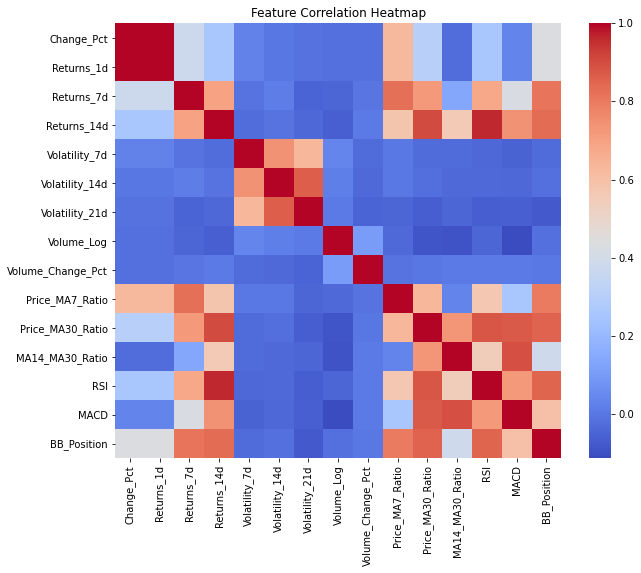

In [19]:
# Set path to store figures
figure_path = r"C:\Users\34663\FRE 7773\project\project\report"

# plot the heatmap for feaature correlaation
corr = X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

# save the figure
plt.savefig(os.path.join(figure_path, "feature_corr_heatmap.png"), dpi=300, bbox_inches="tight")

plt.show()

In [20]:
# Find all high correlation pairs (|correlation| > 0.85)
high_corr_pairs = []
for i in corr.columns:
    for j in corr.columns:
        if i < j:  # Only check upper triangle to avoid duplicates
            corr_val = corr.loc[i, j]
            if abs(corr_val) > 0.85:
                high_corr_pairs.append({
                    'Feature1': i,
                    'Feature2': j,
                    'Correlation': corr_val
                })

# Convert to DataFrame for better display
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False)
    
    print(f"Found {len(high_corr_pairs)} high correlation pairs (|correlation| > 0.85):\n")
    print(high_corr_df.to_string(index=False))
    
    # Also print summary statistics
    print(f"\nSummary:")
    print(f"  Total pairs: {len(high_corr_pairs)}")
    print(f"  Positive correlations: {(high_corr_df['Correlation'] > 0).sum()}")
    print(f"  Negative correlations: {(high_corr_df['Correlation'] < 0).sum()}")
    print(f"  Max correlation: {high_corr_df['Correlation'].abs().max():.4f}")
    print(f"  Min correlation: {high_corr_df['Correlation'].abs().min():.4f}")
else:
    print("No high correlation pairs found (|correlation| > 0.85)")

# Store the DataFrame for further use
high_corr_df

# Save to CSV file
output_path = Path("../data/high_correlation_pairs.csv")
high_corr_df.to_csv(output_path, index=False)
print(f"\nHigh correlation pairs saved to: {output_path}")

Found 9 high correlation pairs (|correlation| > 0.85):

        Feature1         Feature2  Correlation
      Change_Pct       Returns_1d     0.999998
             RSI      Returns_14d     0.963235
Price_MA30_Ratio      Returns_14d     0.902777
 MA14_MA30_Ratio             MACD     0.893345
Price_MA30_Ratio              RSI     0.879208
            MACD Price_MA30_Ratio     0.873977
  Volatility_14d   Volatility_21d     0.863965
     BB_Position Price_MA30_Ratio     0.855343
     BB_Position              RSI     0.851730

Summary:
  Total pairs: 9
  Positive correlations: 9
  Negative correlations: 0
  Max correlation: 1.0000
  Min correlation: 0.8517

High correlation pairs saved to: ..\data\high_correlation_pairs.csv


In [22]:
# Dropped features
X = X.drop(['Change_Pct', 'Returns_14d'], axis=1)

Explained Variance Ratio for first 10 components:
PC1: 0.3875 (38.75%)
PC2: 0.1921 (19.21%)
PC3: 0.1394 (13.94%)
PC4: 0.0847 (8.47%)
PC5: 0.0685 (6.85%)
PC6: 0.0497 (4.97%)
PC7: 0.0294 (2.94%)
PC8: 0.0182 (1.82%)
PC9: 0.0101 (1.01%)
PC10: 0.0090 (0.90%)

Cumulative variance for first 10 components: 0.9886 (98.86%)

Top 10 Features based on PCA:
        Feature  Importance
     Returns_7d    2.238855
     Returns_1d    2.093243
 Volatility_21d    2.036509
 Volatility_14d    1.905778
Price_MA7_Ratio    1.856713
  Volatility_7d    1.787062
            RSI    1.759795
     Volume_Log    1.746858
    BB_Position    1.633906
MA14_MA30_Ratio    1.624726


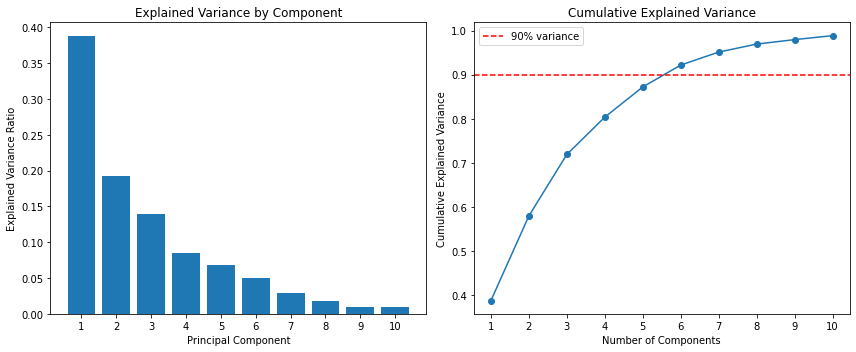

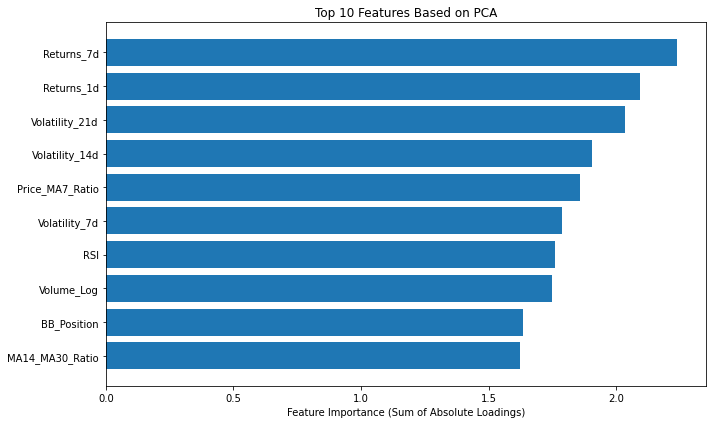


Top 10 Feature Names:
['Returns_7d', 'Returns_1d', 'Volatility_21d', 'Volatility_14d', 'Price_MA7_Ratio', 'Volatility_7d', 'RSI', 'Volume_Log', 'BB_Position', 'MA14_MA30_Ratio']


In [23]:
# PCA Analysis to determine top 10 features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print explained variance for first 10 components
print("Explained Variance Ratio for first 10 components:")
for i in range(min(10, len(explained_variance))):
    print(f"PC{i+1}: {explained_variance[i]:.4f} ({explained_variance[i]*100:.2f}%)")

print(f"\nCumulative variance for first 10 components: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%)")

# Get component loadings (correlations between features and principal components)
component_loadings = pca.components_.T  # Transpose to get features x components

# Calculate feature importance based on absolute loadings across top components
# We'll use the first 10 components to determine top features
n_components_to_use = min(10, len(pca.components_))
feature_importance = np.abs(component_loadings[:, :n_components_to_use]).sum(axis=1)

# Create DataFrame with feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Features based on PCA:")
print(feature_importance_df.head(10).to_string(index=False))

# Visualize explained variance
plt.figure(figsize=(12, 5))

# Plot 1: Explained variance per component
plt.subplot(1, 2, 1)
plt.bar(range(1, min(11, len(explained_variance)+1)), explained_variance[:10])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.xticks(range(1, min(11, len(explained_variance)+1)))

# Plot 2: Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, min(11, len(cumulative_variance)+1)), cumulative_variance[:10], marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.legend()
plt.xticks(range(1, min(11, len(cumulative_variance)+1)))

plt.tight_layout()
plt.show()

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_10_features = feature_importance_df.head(10)
plt.barh(range(len(top_10_features)), top_10_features['Importance'].values)
plt.yticks(range(len(top_10_features)), top_10_features['Feature'].values)
plt.xlabel('Feature Importance (Sum of Absolute Loadings)')
plt.title('Top 10 Features Based on PCA')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Store top 10 feature names
top_10_feature_names = top_10_features['Feature'].tolist()
print(f"\nTop 10 Feature Names:")
print(top_10_feature_names)

In [24]:
# Combine top 10 features with target and save to ready_to_train.csv
# Extract top 10 features from X
X_top10 = X[top_10_feature_names].copy()

# Get target variable from train_df
y = train_df[['Target']].copy()

# Combine features and target
ready_to_train = pd.concat([X_top10, y], axis=1)

print(f"Ready to train dataset shape: {ready_to_train.shape}")
print(f"\nColumns in ready_to_train:")
print(list(ready_to_train.columns))
print(f"\nFirst few rows:")
print(ready_to_train.head())

# Save to CSV
output_path = Path("../data/ready_to_train.csv")
ready_to_train.to_csv(output_path, index=True)
print(f"\nDataset saved to: {output_path}")
print(f"Total rows: {len(ready_to_train)}")
print(f"Total columns: {len(ready_to_train.columns)} (10 features + 1 target)")

Ready to train dataset shape: (1716, 11)

Columns in ready_to_train:
['Returns_7d', 'Returns_1d', 'Volatility_21d', 'Volatility_14d', 'Price_MA7_Ratio', 'Volatility_7d', 'RSI', 'Volume_Log', 'BB_Position', 'MA14_MA30_Ratio', 'Target']

First few rows:
            Returns_7d  Returns_1d  Volatility_21d  Volatility_14d  \
Date                                                                 
2015-10-16    0.077061    0.003898        0.300158        0.338214   
2015-10-19    0.070296   -0.007765        0.291615        0.342046   
2015-10-20    0.001125   -0.004751        0.291129        0.344786   
2015-10-21   -0.038248   -0.025555        0.303543        0.356182   
2015-10-22   -0.009577    0.013256        0.306133        0.357980   

            Price_MA7_Ratio  Volatility_7d        RSI  Volume_Log  \
Date                                                                
2015-10-16         1.015938       0.403181  71.212121    7.754053   
2015-10-19         0.998605       0.412935  68.713